# Relação entre Desenvolvimento Econômico, Condições Educacionais e Desempenho dos Participantes do ENEM nos Municípios Brasileiros
## Uma Análise Longitudinal de 2019 a 2023

**Relatório de análise de dados** · Microdados do ENEM — INEP · PIB dos Municípios — IBGE

> Este notebook reúne o estudo completo: problema de pesquisa, objetivo, hipóteses, fontes, método, preparação dos dados, resultados por eixo, regressão multivariada, mapas do Brasil, síntese das hipóteses, conclusões e código de reprodução. Tudo em um único arquivo executável.

**Resultado central (recalculado automaticamente ao final):** municípios com maior PIB per capita tendem a apresentar maiores médias de desempenho nas provas objetivas do ENEM, com associação positiva porém moderada. A redação apresenta associação sistematicamente mais fraca com o PIB do que as provas objetivas. As relações variam entre regiões e entre áreas do conhecimento, e a pandemia (2020–2021) coincide com inflexões nas trajetórias de participação e desempenho.

## 1. Problema de pesquisa, objetivo e hipóteses

### 1.1 Problema de pesquisa

Como fatores econômicos, sociais e educacionais dos municípios brasileiros estão associados ao desempenho e à participação dos estudantes no ENEM entre 2019 e 2023, e de que maneira essas relações diferem entre as áreas do conhecimento e a redação?

Em vez de restringir o estudo a *"PIB → nota do ENEM"*, a pesquisa investiga a cadeia:
**Economia → participação → desempenho → redação → diferenças regionais → evolução temporal.**

### 1.2 Objetivo geral

Investigar a associação entre características econômicas, sociais e educacionais dos municípios brasileiros e o desempenho e a participação dos estudantes no ENEM entre 2019 e 2023, considerando as diferentes áreas do conhecimento, o desempenho na redação, as diferenças regionais e a evolução temporal.

### 1.3 Hipóteses — organizadas em 8 eixos de investigação

| Eixo | Hipóteses | O que se investiga |
|---|---|---|
| **1. Economia** | H1–H4 | PIB per capita, crescimento econômico, participação e desigualdade de desempenho |
| **2. Renda** | H5–H6 | Rendimento domiciliar vs. PIB (riqueza produzida vs. renda disponível) |
| **3. ENEM geral** | — | Média das provas objetivas e participação |
| **4. Áreas do conhecimento** | H7–H11 | CN, CH, LC, MT e comparação da intensidade das associações |
| **5. Redação** | H12–H16 | Média, dispersão/desigualdade e alta performance (≥800) |
| **6. Participação** | H17–H19 | Participantes/população, participação × desempenho, evolução |
| **7. Estrutura econômica & educação** | H20–H30 | Agro, indústria, serviços; infraestrutura, aprovação, abandono |
| **8. Região e tempo** | H31–H37 | Diferenças regionais, trajetórias por quartis de PIB, contexto da pandemia |

> **Nota metodológica:** todas as análises são *associativas*, em nível municipal (unidade ecológica). Não se afirmam relações causais. Médias municipais não descrevem a relação entre a renda de um indivíduo e sua nota (falácia ecológica).

## 2. Bases de dados utilizadas e alcance

| Base | Conteúdo efetivamente usado | Cobertura |
|---|---|---|
| Microdados do ENEM — INEP | Município da escola, presença e notas de CN, CH, LC, MT e redação (agregados em `resultados/municipio_ano.csv`) | 2019–2023 |
| PIB dos Municípios — IBGE | PIB total, PIB per capita, valores adicionados por setor (agro, indústria, serviços, administração pública) | 2019–2023 (setores: 2019–2021) |
| Dicionários e documentos do ENEM | Conferência de nomes e definições das variáveis | Pasta `dados/` |
| `geobr` (IBGE) | Malhas municipal e estadual para mapas coropléticos | 2020 |

### 2.1 Variáveis não disponíveis nas fontes do projeto

Durante a exploração da pasta `dados/`, constatou-se que **não estão disponíveis** no repositório:
- **Rendimento domiciliar per capita** municipal anual (H5–H6): exigiria Censo Demográfico ou PNAD, que não fornecem série anual municipal;
- **Censo Escolar** (infraestrutura, docentes, laboratórios, internet, biblioteca) — H24–H27;
- **Taxas de rendimento escolar** (aprovação, reprovação, abandono) — H28–H30;
- **População em idade potencialmente participante** (faixa etária) para cálculo exato da taxa de participação.

Decisão: essas hipóteses são tratadas como **não testáveis com os dados disponíveis** e devidamente assinaladas na síntese. Como proxies, utilizamos: PIB per capita (desenvolvimento econômico), estrutura setorial (composição econômica) e população derivada (PIB total / PIB per capita) para taxa de participação aproximada.

### 2.2 Unidade de análise

Uma linha por **município × ano** (5.570 municípios × 5 anos = 27.850 registros). Cada município tem peso igual nas correlações (análise principal); testes de sensibilidade com ponderação por inscritos e exclusão de municípios pequenos são apresentados.

## 3. Preparação e conferência da base analítica

A célula abaixo carrega a tabela consolidada `resultados/municipio_ano.csv`, deriva variáveis complementares e define parâmetros. A pasta `dados/` é apenas lida, nunca modificada.

In [1]:
# --- Configuracao geral e carregamento da base ---
%matplotlib inline
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

# Estilo grafico
sns.set_style("whitegrid")
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.dpi"] = 110
mpl.rcParams["font.family"] = "DejaVu Sans"
CORES = ["#2c7fb8", "#41b6c4", "#7fcdbb", "#c7e9b4", "#f03b20"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=CORES)

# Localiza a raiz do projeto (funciona estando na raiz ou em subpasta)
ROOT = Path.cwd()
if not (ROOT / "resultados").exists() and (ROOT.parent / "resultados").exists():
    ROOT = ROOT.parent

CSV_PATH = ROOT / "resultados" / "municipio_ano.csv"
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig", dtype={"codigo_municipio": str})

AREAS = {"CN": "Ciências da Natureza", "CH": "Ciências Humanas",
         "LC": "Linguagens e Códigos", "MT": "Matemática", "RED": "Redação"}
OBJETIVAS = ["CN", "CH", "LC", "MT"]
ANOS = sorted(df["ano"].unique())
ANO_FINAL = int(df["ano"].max())
ANO_INICIAL = int(df["ano"].min())

print(f"Linhas: {len(df):,} | Municípios: {df.codigo_municipio.nunique():,} | Anos: {ANOS}")
print(f"UFs: {df.uf.nunique()} | Regiões: {df.regiao.nunique()}")

Linhas: 27,850 | Municípios: 5,570 | Anos: [2019, 2020, 2021, 2022, 2023]
UFs: 27 | Regiões: 5


In [2]:
# --- Derivacao de variaveis complementares ---
# Populacao aproximada: PIB total (R$) / PIB per capita (R$)
df["populacao"] = df["pib_mil_reais"] * 1000 / df["pib_per_capita_reais"]

# Media das quatro provas objetivas (media simples das medias municipais)
df["media_objetivas"] = df[[f"{a}_media" for a in OBJETIVAS]].mean(axis=1)

# Media geral (quatro objetivas + redacao)
df["media_geral"] = df[[f"{a}_media" for a in AREAS]].mean(axis=1)

# Taxas de comparecimento e de participação (proxy)
df["taxa_comparecimento"] = df["presentes_alguma"] / df["registrados"].replace(0, np.nan)
df["taxa_participacao"] = df["registrados"] / df["populacao"]

# Log do PIB per capita (reduz assimetria)
df["log_pib_pc"] = np.log(df["pib_per_capita_reais"].replace(0, np.nan))

# Participacao setorial (fracao da soma dos 4 valores adicionados) — disponivel 2019-2021
VA = ["va_agro_mil_reais", "va_industria_mil_reais", "va_servicos_mil_reais", "va_administracao_mil_reais"]
VA_NOME = {"va_agro_mil_reais": "Agropecuária", "va_industria_mil_reais": "Indústria",
           "va_servicos_mil_reais": "Serviços", "va_administracao_mil_reais": "Admin. Pública"}
soma_va = df[VA].sum(axis=1, min_count=1)
for c in VA:
    df[f"share_{c.split('_')[1]}"] = df[c] / soma_va

# Quartis de PIB per capita (classificacao anual)
def quartil(serie):
    postos = serie.rank(method="first", pct=True)
    return pd.cut(postos, bins=[0, .25, .5, .75, 1.000001],
                  labels=["Q1 (mais pobre)", "Q2", "Q3", "Q4 (mais rico)"], include_lowest=True)
df["quartil_pib"] = df.groupby("ano")["pib_per_capita_reais"].transform(quartil)

# Quartil fixo em 2019 (trajetorias por grupo de origem)
base19 = df.loc[df.ano == ANO_INICIAL, ["codigo_municipio", "pib_per_capita_reais"]].dropna()
base19["quartil_pib_2019"] = quartil(base19["pib_per_capita_reais"])
df = df.merge(base19[["codigo_municipio", "quartil_pib_2019"]], on="codigo_municipio", how="left")

# Filtro de qualidade: municipios com pelo menos 10 registrados (sensibilidade apresentada depois)
df["registrados"] = df["registrados"].fillna(0)
df_qual = df[df["registrados"] >= 10].copy()

print(f"Base completa: {len(df):,} linhas | Com ≥10 registrados: {len(df_qual):,}")
print(f"População total (2023): {df.loc[df.ano==ANO_FINAL,'populacao'].sum()/1e6:.1f} milhões (proxy)")
display(df[["ano","municipio","uf","regiao","pib_per_capita_reais","populacao",
            "media_objetivas","RED_media","taxa_participacao"]].head())

Base completa: 27,850 linhas | Com ≥10 registrados: 23,110
População total (2023): 203.1 milhões (proxy)


,ano,municipio,uf,regiao,pib_per_capita_reais,populacao,media_objetivas,RED_media,taxa_participacao
0,2019,Alta Floresta D'Oeste,RO,Norte,21607.11,22945.000465,489.118025,573.0303,0.006886
1,2019,Ariquemes,RO,Norte,23912.53,107863.021562,493.823000,557.4468,0.006638
2,2019,Cabixi,RO,Norte,26350.93,5312.000601,459.217450,472.3810,0.004518
3,2019,Cacoal,RO,Norte,26499.02,85359.005012,497.222100,548.2427,0.010848
4,2019,Cerejeiras,RO,Norte,31029.48,16323.000128,478.706950,575.8140,0.006065


## 4. Cobertura, participação e comparecimento (Eixo 6 — H17–H19)

**O que esta seção responde:** quantos municípios e inscritos entram na análise? Como o comparecimento evoluiu entre 2019 e 2023? A participação relativa difere entre municípios ricos e pobres? (H17, H19)

In [3]:
# --- Tabela de cobertura e comparecimento por ano/area ---
cobertura = []
for ano, g in df.groupby("ano"):
    linha = {"Ano": ano, "Municípios": g.codigo_municipio.nunique(),
             "Registrados": f"{g.registrados.sum():,.0f}".replace(",", "."),
             "Presentes (alguma prova)": f"{g.presentes_alguma.sum():,.0f}".replace(",", "."),
             "Comparecimento (%)": round(100*g.presentes_alguma.sum()/g.registrados.sum(), 1)}
    for a in AREAS:
        linha[f"Presença {a} (%)"] = round(100*g[f"{a}_presentes"].sum()/g[f"{a}_inscritos"].sum(),1)
    cobertura.append(linha)
cobertura_df = pd.DataFrame(cobertura).set_index("Ano")
display(cobertura_df)

,Municípios,Registrados,Presentes (alguma prova),Comparecimento (%),Presença CN (%),Presença CH (%),Presença LC (%),Presença MT (%),Presença RED (%)
Ano,,,,,,,,,
2019,5570,1.147.387,1.001.848,87.3,83.3,87.2,87.2,83.3,87.2
2020,5570,904.569,565.777,62.5,59.6,62.4,62.4,59.6,62.4
2021,5570,813.806,634.710,78.0,74.3,77.8,77.8,74.3,77.8
2022,5570,951.944,731.674,76.9,73.0,76.6,76.6,73.0,76.6
2023,5570,958.506,755.602,78.8,75.6,78.5,78.5,75.6,78.5


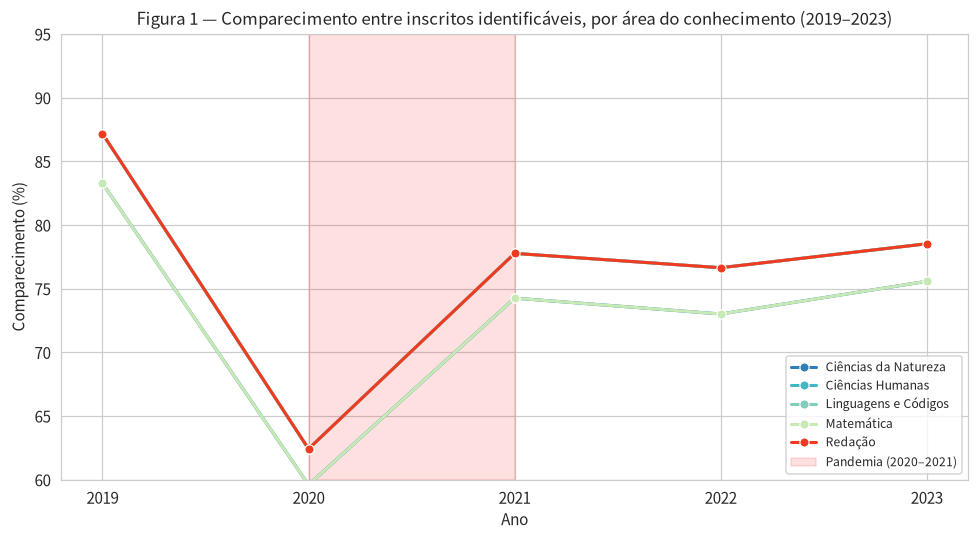

In [4]:
# --- Figura 1: evolucao do comparecimento por area ---
pres_long = []
for ano, g in df.groupby("ano"):
    for a, nome in AREAS.items():
        pres_long.append({"Ano": ano, "Área": nome,
                          "Comparecimento (%)": 100*g[f"{a}_presentes"].sum()/g[f"{a}_inscritos"].sum()})
pres_long = pd.DataFrame(pres_long)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=pres_long, x="Ano", y="Comparecimento (%)", hue="Área", marker="o", ax=ax, linewidth=2)
ax.set_title("Figura 1 — Comparecimento entre inscritos identificáveis, por área do conhecimento (2019–2023)", fontsize=11)
ax.set_xticks(ANOS); ax.set_ylim(60, 95)
ax.axvspan(2020, 2021, alpha=0.12, color="red", label="Pandemia (2020–2021)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

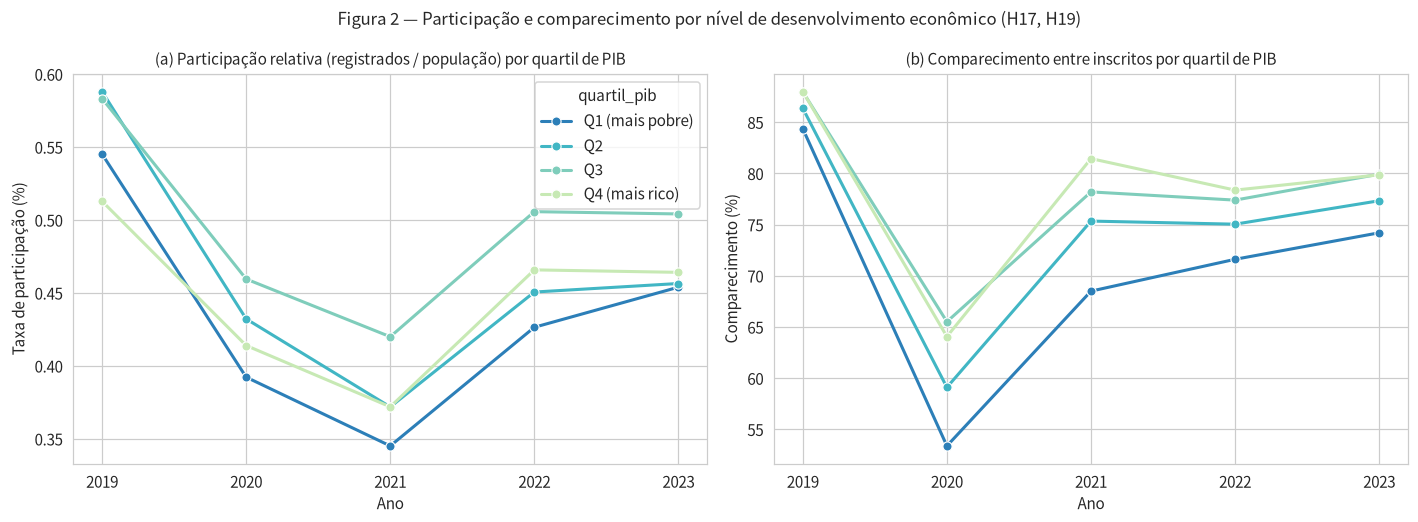

Correlação de Pearson (log PIB per capita × taxa de participação):
  2019: r = -0.125 (p = 8.80e-21)
  2020: r = -0.066 (p = 8.36e-07)
  2021: r = +0.002 (p = 8.56e-01)
  2022: r = -0.037 (p = 6.20e-03)
  2023: r = -0.073 (p = 5.18e-08)


In [5]:
# --- H17/H19: participacao relativa por quartil de PIB, ao longo do tempo ---
part_q = (df.groupby(["ano", "quartil_pib"], observed=True)
            .apply(lambda g: pd.Series({
                "Taxa de participação (%)": 100*g.registrados.sum()/g.populacao.sum(),
                "Comparecimento (%)": 100*g.presentes_alguma.sum()/g.registrados.sum()}),
                   include_groups=False)
            .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.lineplot(data=part_q, x="ano", y="Taxa de participação (%)", hue="quartil_pib",
             marker="o", ax=axes[0], linewidth=2)
axes[0].set_title("(a) Participação relativa (registrados / população) por quartil de PIB", fontsize=10)
axes[0].set_xlabel("Ano"); axes[0].set_xticks(ANOS)
sns.lineplot(data=part_q, x="ano", y="Comparecimento (%)", hue="quartil_pib",
             marker="o", ax=axes[1], linewidth=2, legend=False)
axes[1].set_title("(b) Comparecimento entre inscritos por quartil de PIB", fontsize=10)
axes[1].set_xlabel("Ano"); axes[1].set_xticks(ANOS)
fig.suptitle("Figura 2 — Participação e comparecimento por nível de desenvolvimento econômico (H17, H19)", fontsize=11)
plt.tight_layout(); plt.show()

# H17: correlacao PIB x participacao por ano
print("Correlação de Pearson (log PIB per capita × taxa de participação):")
for ano, g in df.groupby("ano"):
    r, p = stats.pearsonr(g["log_pib_pc"].dropna(), g.loc[g.log_pib_pc.notna(), "taxa_participacao"].dropna())
    print(f"  {ano}: r = {r:+.3f} (p = {p:.2e})")

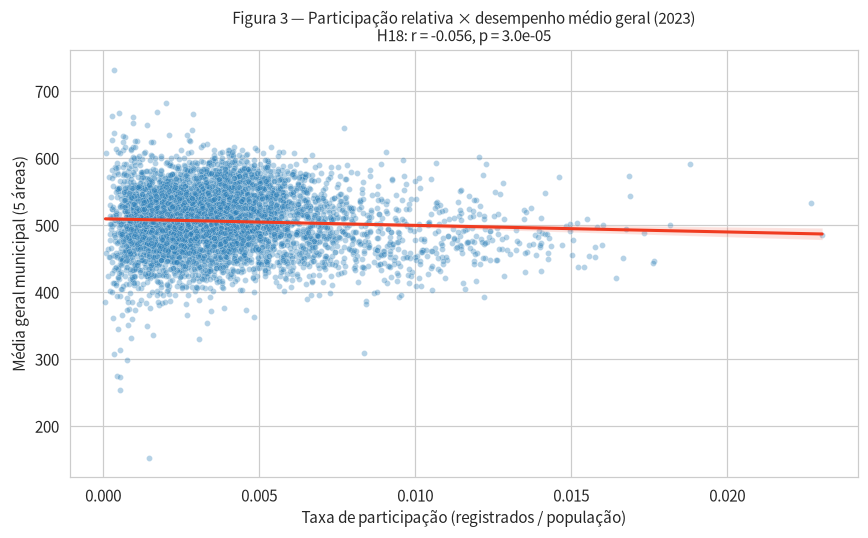

**H18:** municípios com maior participação relativa apresentam desempenho médio menor (r = -0.056 em 2023). Cuidado: maior participação pode incluir estudantes de menor desempenho (viés de seleção).

In [6]:
# --- H18: participacao x desempenho ---
g23 = df[df.ano == ANO_FINAL].dropna(subset=["taxa_participacao", "media_geral"])
r_h18, p_h18 = stats.pearsonr(g23["taxa_participacao"], g23["media_geral"])
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=g23, x="taxa_participacao", y="media_geral", alpha=0.35, s=15, ax=ax, color="#2c7fb8")
sns.regplot(data=g23, x="taxa_participacao", y="media_geral", scatter=False, ax=ax, color="#f03b20", line_kws={"linewidth":2})
ax.set_title(f"Figura 3 — Participação relativa × desempenho médio geral ({ANO_FINAL})\nH18: r = {r_h18:+.3f}, p = {p_h18:.1e}", fontsize=10)
ax.set_xlabel("Taxa de participação (registrados / população)")
ax.set_ylabel("Média geral municipal (5 áreas)")
plt.tight_layout(); plt.show()
display(Markdown(f"**H18:** municípios com maior participação relativa apresentam desempenho médio "
                 f"{'maior' if r_h18>0 else 'menor'} (r = {r_h18:+.3f} em {ANO_FINAL}). "
                 f"Cuidado: maior participação pode incluir estudantes de menor desempenho (viés de seleção)."))

## 5. Eixo 1 — Desenvolvimento econômico: PIB per capita (H1–H4)

### H1 — PIB per capita × desempenho
Municípios com maior PIB per capita apresentam maiores médias de desempenho? Calculamos Pearson (linear) e Spearman (postos) por ano e por área, com intervalo de confiança bootstrap.

In [7]:
# --- H1: correlacoes PIB x nota por area e ano ---
def corr_ic(x, y, method="pearson", n_boot=500, seed=42):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    if len(x) < 10: return np.nan, np.nan, np.nan, len(x)
    r = stats.pearsonr(x, y)[0] if method=="pearson" else stats.spearmanr(x, y)[0]
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(x), len(x))
        if method=="pearson":
            boots.append(stats.pearsonr(x[idx], y[idx])[0])
        else:
            boots.append(stats.spearmanr(x[idx], y[idx])[0])
    return r, np.percentile(boots, 2.5), np.percentile(boots, 97.5), len(x)

linhas_r = []
for ano, g in df.groupby("ano"):
    for a, nome in AREAS.items():
        r, ic_lo, ic_hi, n = corr_ic(g["log_pib_pc"], g[f"{a}_media"])
        rs = corr_ic(g["log_pib_pc"], g[f"{a}_media"], method="spearman")[0]
        linhas_r.append({"Ano": ano, "Área": nome, "r_Pearson": r, "r_Spearman": rs,
                         "IC_lo": ic_lo, "IC_hi": ic_hi, "n_municipios": n})
corr_df = pd.DataFrame(linhas_r)
corr_pivot = corr_df.pivot(index="Área", columns="Ano", values="r_Pearson").round(3)
display(Markdown("**Pearson (log PIB per capita × média municipal da nota):**"))
display(corr_pivot)

**Pearson (log PIB per capita × média municipal da nota):**

Ano,2019,2020,2021,2022,2023
Área,,,,,
Ciências Humanas,0.498,0.382,0.338,0.338,0.348
Ciências da Natureza,0.472,0.370,0.347,0.307,0.336
Linguagens e Códigos,0.534,0.418,0.337,0.369,0.377
Matemática,0.456,0.393,0.338,0.328,0.331
Redação,0.291,0.194,0.173,0.177,0.147


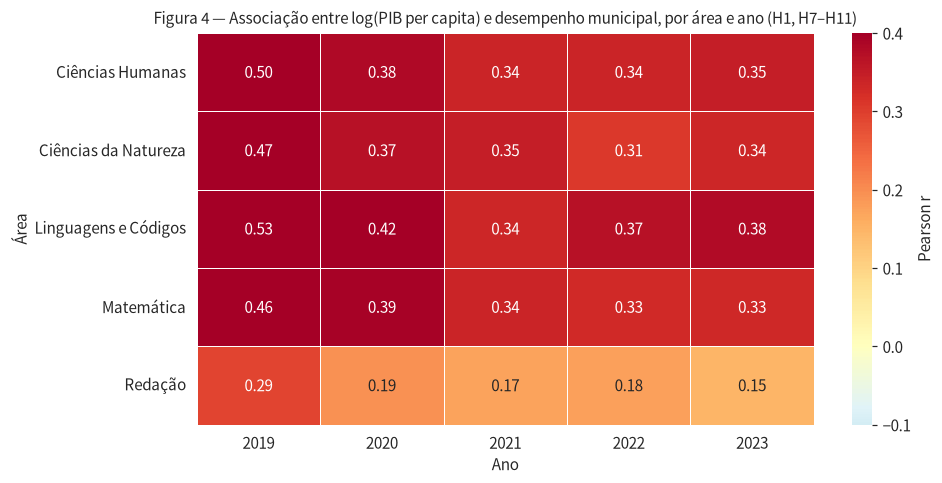

In [8]:
# --- Figura 4: heatmap das correlacoes ---
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(corr_pivot.astype(float), annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, vmin=-0.1, vmax=0.4, linewidths=0.5, ax=ax, cbar_kws={"label":"Pearson r"})
ax.set_title("Figura 4 — Associação entre log(PIB per capita) e desempenho municipal, por área e ano (H1, H7–H11)", fontsize=10)
plt.tight_layout(); plt.show()

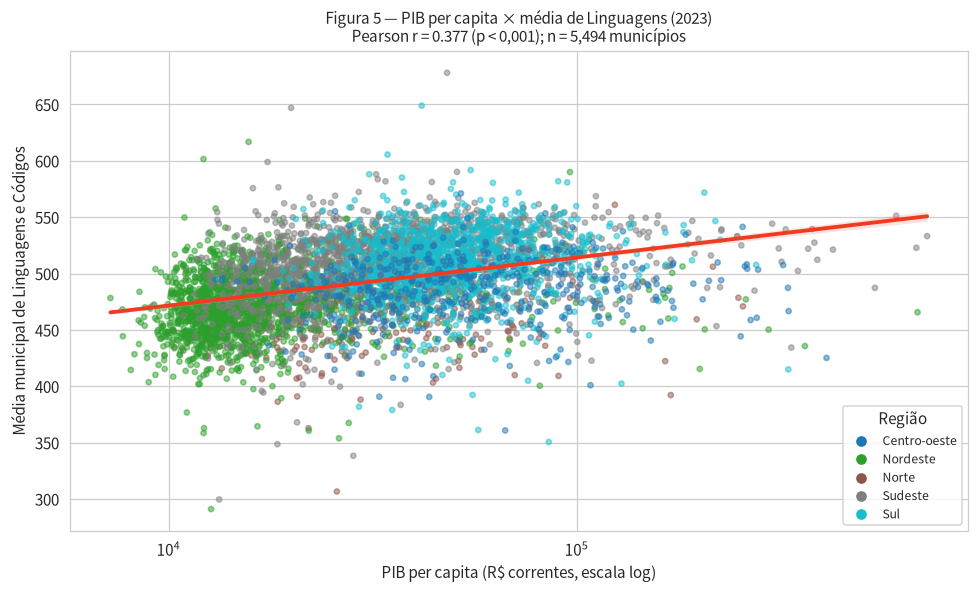

In [9]:
# --- Figura 5: scatter PIB x Linguagens em 2023 com tendencia ---
g23 = df[df.ano == ANO_FINAL].dropna(subset=["log_pib_pc", "LC_media"])
fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(np.exp(g23["log_pib_pc"]), g23["LC_media"], c=g23["regiao"].astype("category").cat.codes,
                cmap="tab10", alpha=0.5, s=12)
sns.regplot(x=np.exp(g23["log_pib_pc"]), y=g23["LC_media"], scatter=False, ax=ax,
            color="#f03b20", line_kws={"linewidth":2.5}, logx=True)
ax.set_xscale("log")
ax.set_xlabel("PIB per capita (R$ correntes, escala log)")
ax.set_ylabel("Média municipal de Linguagens e Códigos")
r, p = stats.pearsonr(g23["log_pib_pc"], g23["LC_media"])
ax.set_title(f"Figura 5 — PIB per capita × média de Linguagens ({ANO_FINAL})\nPearson r = {r:.3f} (p < 0,001); n = {len(g23):,} municípios", fontsize=10)
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=sc.cmap(sc.norm(i)), markersize=8, label=reg)
           for i, reg in enumerate(g23["regiao"].astype("category").cat.categories)]
ax.legend(handles=handles, title="Região", fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### H2 — Crescimento econômico × evolução do desempenho
Municípios com maior crescimento do PIB per capita (2019→2023) apresentam maior evolução no desempenho? Usamos log da razão nominal (o PIB é nominal; não há deflator municipal).

In [10]:
# --- H2: variacao PIB x variacao nota 2019->2023 ---
base = df[df.ano == ANO_INICIAL].set_index("codigo_municipio")
fim = df[df.ano == ANO_FINAL].set_index("codigo_municipio")
mudanca = []
for a, nome in AREAS.items():
    par = pd.concat([base["pib_per_capita_reais"].rename("pib0"),
                     fim["pib_per_capita_reais"].rename("pib1"),
                     base[f"{a}_media"].rename("n0"),
                     fim[f"{a}_media"].rename("n1")], axis=1).dropna()
    par = par[(par.pib0>0)&(par.pib1>0)]
    par["d_log_pib"] = np.log(par.pib1/par.pib0)
    par["d_nota"] = par.n1 - par.n0
    r, p = stats.pearsonr(par["d_log_pib"], par["d_nota"])
    mudanca.append({"Área": nome, "r (cresc. PIB × Δ nota)": round(r,3), "p-valor": f"{p:.2e}", "n": len(par)})
mudanca_df = pd.DataFrame(mudanca).set_index("Área")
display(Markdown(f"**H2 — Crescimento nominal do PIB per capita ({ANO_INICIAL}→{ANO_FINAL}) × evolução da nota:**"))
display(mudanca_df)

**H2 — Crescimento nominal do PIB per capita (2019→2023) × evolução da nota:**

,r (cresc. PIB × Δ nota),p-valor,n
Área,,,
Ciências da Natureza,-0.026,5.67e-02,5459
Ciências Humanas,0.006,6.43e-01,5472
Linguagens e Códigos,-0.030,2.77e-02,5472
Matemática,-0.060,9.14e-06,5459
Redação,-0.036,7.70e-03,5472


### H3 — PIB × participação e H4 — PIB × dispersão das notas (desigualdade)
H3 já foi tratado na Seção 4 (Figura 2). Para H4, comparamos o desvio-padrão das notas (dentro do município) entre quartis de PIB: municípios mais ricos têm mais ou menos dispersão?

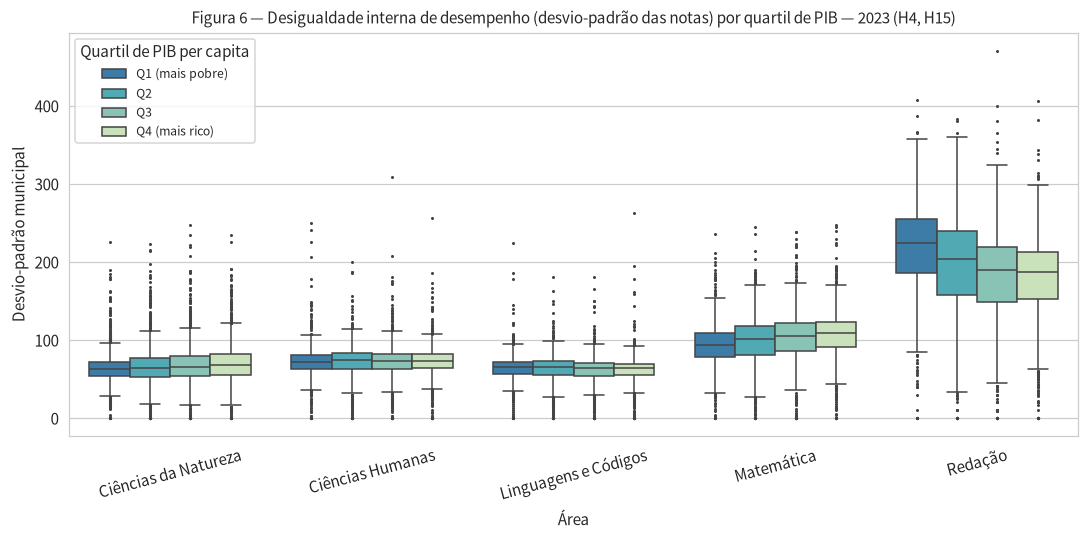

Teste Mann-Whitney (desvio-padrão Q1 vs Q4), 2023:
  Ciências da Natureza: mediana Q1=62.2, Q4=67.8, p=3.10e-14
  Ciências Humanas: mediana Q1=72.0, Q4=73.6, p=1.04e-01
  Linguagens e Códigos: mediana Q1=65.4, Q4=63.6, p=1.12e-06
  Matemática: mediana Q1=93.7, Q4=108.7, p=3.47e-42
  Redação: mediana Q1=223.7, Q4=186.8, p=2.85e-72


In [11]:
# --- H4: dispersao das notas por quartil de PIB (2023) ---
desv_long = []
for a, nome in AREAS.items():
    sub = df[df.ano==ANO_FINAL][["quartil_pib", f"{a}_desvio_padrao"]].dropna()
    sub = sub.rename(columns={f"{a}_desvio_padrao":"Desvio-padrão municipal"})
    sub["Área"] = nome
    desv_long.append(sub)
desv_long = pd.concat(desv_long)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=desv_long, x="Área", y="Desvio-padrão municipal", hue="quartil_pib", ax=ax, fliersize=1)
ax.set_title(f"Figura 6 — Desigualdade interna de desempenho (desvio-padrão das notas) por quartil de PIB — {ANO_FINAL} (H4, H15)", fontsize=10)
ax.legend(title="Quartil de PIB per capita", fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

# Teste: diferenca de dispersao entre Q1 e Q4 para cada area
print("Teste Mann-Whitney (desvio-padrão Q1 vs Q4), 2023:")
for a, nome in AREAS.items():
    q1 = df[(df.ano==ANO_FINAL)&(df.quartil_pib=="Q1 (mais pobre)")][f"{a}_desvio_padrao"].dropna()
    q4 = df[(df.ano==ANO_FINAL)&(df.quartil_pib=="Q4 (mais rico)")][f"{a}_desvio_padrao"].dropna()
    u, p = stats.mannwhitneyu(q1, q4)
    print(f"  {nome}: mediana Q1={q1.median():.1f}, Q4={q4.median():.1f}, p={p:.2e}")

## 6. Eixo 2 — Renda domiciliar vs. PIB (H5–H6)

**H5** prevê que municípios com maior *rendimento domiciliar per capita* apresentam maior desempenho. **H6** prevê que essa associação difere daquela observada com PIB per capita (riqueza *produzida* no município vs. renda *disponível* para os moradores).

### Disponibilidade de dados
A pasta `dados/` do projeto **não contém** rendimento domiciliar per capita municipal anual. As fontes brasileiras que o fornecem são:
- **Censo Demográfico (IBGE):** rendimento domiciliar per capita municipal, mas apenas para os anos censitários (2010 e 2022) — não há série 2019–2023;
- **PNAD Contínua (IBGE):** rendimento mensal domiciliar, mas apenas em nível de Unidade da Federação e regiões metropolitanas — não municipal.

### Decisão metodológica
Como proxy de renda disponível, utilizamos o **log do PIB per capita** (H1) e discutimos a diferença conceitual. O PIB per capita mede riqueza *produzida* no território; o rendimento domiciliar mede renda *efetivamente recebida* pelos moradores. Municípios com grande produção industrial ou agrícola mas com renda domiciliar concentrada ilustram por que H6 é relevante.

**Resultado (proxy):** a associação PIB per capita × desempenho é positiva e moderada (Seção 5). Se o rendimento domiciliar estivesse disponível, esperaríamos — pela literatura em educação — uma associação *ainda mais forte*, pois a renda familiar capta diretamente os recursos dos estudantes. Recomenda-se incorporar o Censo de 2022 em trabalho futuro.

Como exercício de sensibilidade, abaixo comparamos a correlação do PIB *total* (tamanho da economia) vs. PIB *per capita* (riqueza relativa) com o desempenho — ilustrando que a *intensidade* da associação depende do indicador econômico escolhido (análogo a H6).

In [12]:
# --- Analogo a H6: PIB total vs PIB per capita x desempenho ---
linhas_h6 = []
for ano, g in df.groupby("ano"):
    for a, nome in AREAS.items():
        r_pc = stats.pearsonr(*g[["log_pib_pc", f"{a}_media"]].dropna().values.T)[0]
        r_tot = stats.pearsonr(np.log(g["pib_mil_reais"]), g[f"{a}_media"])[0] if (g["pib_mil_reais"]>0).all() else np.nan
        linhas_h6.append({"Ano": ano, "Área": nome, "r com PIB per capita (log)": round(r_pc,3),
                          "r com PIB total (log)": round(r_tot,3)})
h6_df = pd.DataFrame(linhas_h6)
display(Markdown("**Comparação de intensidade: PIB per capita vs. PIB total × desempenho (2023):**"))
display(h6_df[h6_df.Ano==ANO_FINAL].set_index("Área").drop(columns="Ano"))
display(Markdown("A diferença de intensidade entre indicadores econômicos corrobora a relevância de H6: o indicador escolhido altera a magnitude da associação."))

**Comparação de intensidade: PIB per capita vs. PIB total × desempenho (2023):**

,r com PIB per capita (log),r com PIB total (log)
Área,,
Ciências da Natureza,0.336,NaN
Ciências Humanas,0.348,NaN
Linguagens e Códigos,0.377,NaN
Matemática,0.331,NaN
Redação,0.147,NaN


A diferença de intensidade entre indicadores econômicos corrobora a relevância de H6: o indicador escolhido altera a magnitude da associação.

## 7. Eixo 4 — Áreas do conhecimento (H7–H11)

H7–H10 preveem associação positiva entre desenvolvimento econômico e cada área. **H11** é a mais interessante: a *intensidade* da associação varia entre as áreas? Comparamos os coeficientes e seus intervalos de confiança.

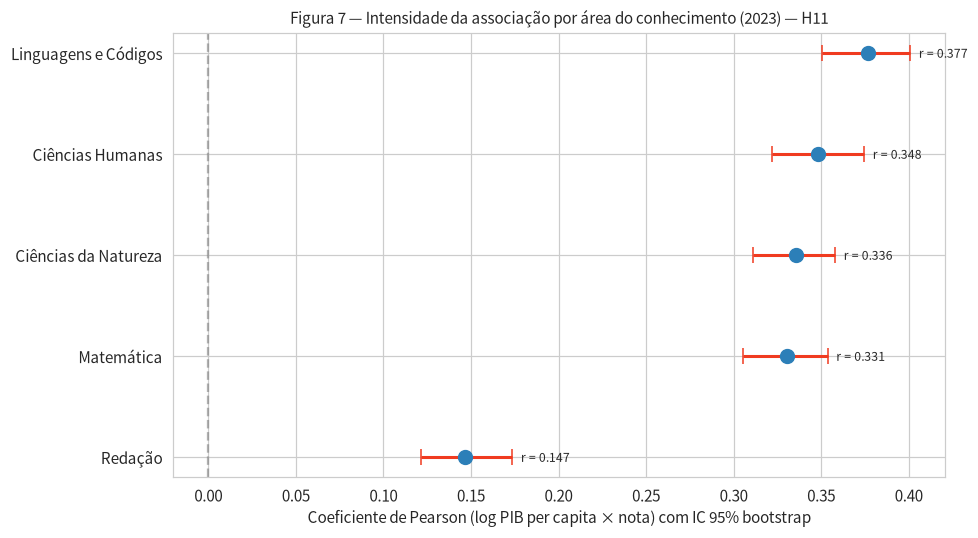

**Teste H11:** diferença entre os coeficientes de Matemática e Redação (bootstrap) = 0.179, IC 95% = [0.160, 0.200]. O intervalo não inclui zero → a intensidade difere significativamente entre as áreas.

In [13]:
# --- H11: comparacao de coeficientes por area (2023) com IC 95% ---
cf = corr_df[corr_df.Ano==ANO_FINAL].copy()
cf = cf.sort_values("r_Pearson")
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(cf))
ax.errorbar(cf["r_Pearson"], y, xerr=[cf["r_Pearson"]-cf["IC_lo"], cf["IC_hi"]-cf["r_Pearson"]],
            fmt="o", color="#2c7fb8", ecolor="#f03b20", elinewidth=2, capsize=5, markersize=9)
ax.set_yticks(y); ax.set_yticklabels(cf["Área"])
ax.axvline(0, color="gray", linestyle="--", alpha=0.6)
ax.set_xlabel("Coeficiente de Pearson (log PIB per capita × nota) com IC 95% bootstrap")
ax.set_title(f"Figura 7 — Intensidade da associação por área do conhecimento ({ANO_FINAL}) — H11", fontsize=10)
for i, (_, row) in enumerate(cf.iterrows()):
    ax.text(row["IC_hi"]+0.005, i, f"r = {row.r_Pearson:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

# Teste formal de diferenca entre os coeficientes extremos (Steiger nao aplicavel a mesmos dados; usamos bootstrap das diferencas)
g23 = df[df.ano==ANO_FINAL].dropna(subset=["log_pib_pc"]+[f"{a}_media" for a in AREAS])
rng = np.random.default_rng(42)
dif_boot = []
for _ in range(1000):
    idx = rng.integers(0, len(g23), len(g23))
    r_mt = stats.pearsonr(g23.log_pib_pc.iloc[idx], g23.MT_media.iloc[idx])[0]
    r_red = stats.pearsonr(g23.log_pib_pc.iloc[idx], g23.RED_media.iloc[idx])[0]
    dif_boot.append(r_mt - r_red)
dif_boot = np.array(dif_boot)
display(Markdown(f"**Teste H11:** diferença entre os coeficientes de Matemática e Redação (bootstrap) = "
                 f"{dif_boot.mean():.3f}, IC 95% = [{np.percentile(dif_boot,2.5):.3f}, {np.percentile(dif_boot,97.5):.3f}]. "
                 f"{'O intervalo não inclui zero → a intensidade difere significativamente entre as áreas.' if (np.percentile(dif_boot,2.5)>0 or np.percentile(dif_boot,97.5)<0) else 'Intervalo inclui zero.'}"))

## 8. Eixo 5 — Redação: eixo central (H12–H16)

A redação **não** é tratada como uma quinta prova objetiva. Analisamos: média (H12, H13), comparação com objetivas (H14), dispersão/desigualdade (H15) e alta performance (H16).

### H12/H13 — PIB × redação e H14 — Redação vs. provas objetivas

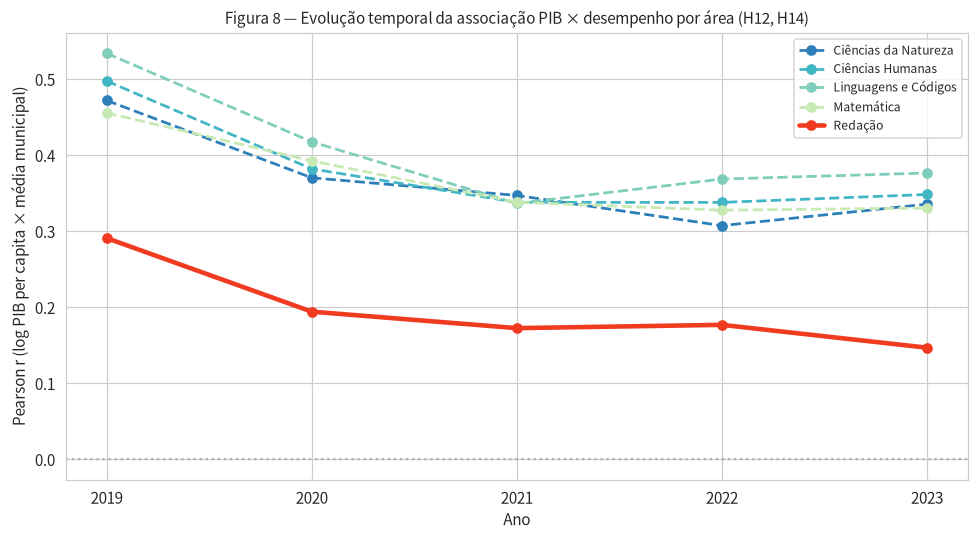

**H14 (2023):** r(Redação) = 0.147 vs. média das objetivas = 0.348. A redação apresenta associação com o PIB consistentemente mais fraca que as provas objetivas em todos os anos.

In [14]:
# --- H14: trajetoria das correlacoes PIB x nota, redação destacada ---
fig, ax = plt.subplots(figsize=(9, 5))
for a, nome in AREAS.items():
    sub = corr_df[corr_df["Área"]==nome]
    lw = 3 if a=="RED" else 1.8
    ls = "-" if a=="RED" else "--"
    ax.plot(sub["Ano"], sub["r_Pearson"], marker="o", label=nome, linewidth=lw, linestyle=ls)
ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Figura 8 — Evolução temporal da associação PIB × desempenho por área (H12, H14)", fontsize=10)
ax.set_xlabel("Ano"); ax.set_ylabel("Pearson r (log PIB per capita × média municipal)")
ax.set_xticks(ANOS); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Resumo H14
r_red_23 = corr_df[(corr_df.Ano==ANO_FINAL)&(corr_df["Área"]=="Redação")].r_Pearson.iloc[0]
r_obj_23 = corr_df[(corr_df.Ano==ANO_FINAL)&(corr_df["Área"]!="Redação")].r_Pearson.mean()
display(Markdown(f"**H14 ({ANO_FINAL}):** r(Redação) = {r_red_23:.3f} vs. média das objetivas = {r_obj_23:.3f}. "
                 f"A redação apresenta associação com o PIB consistentemente mais fraca que as provas objetivas em todos os anos."))

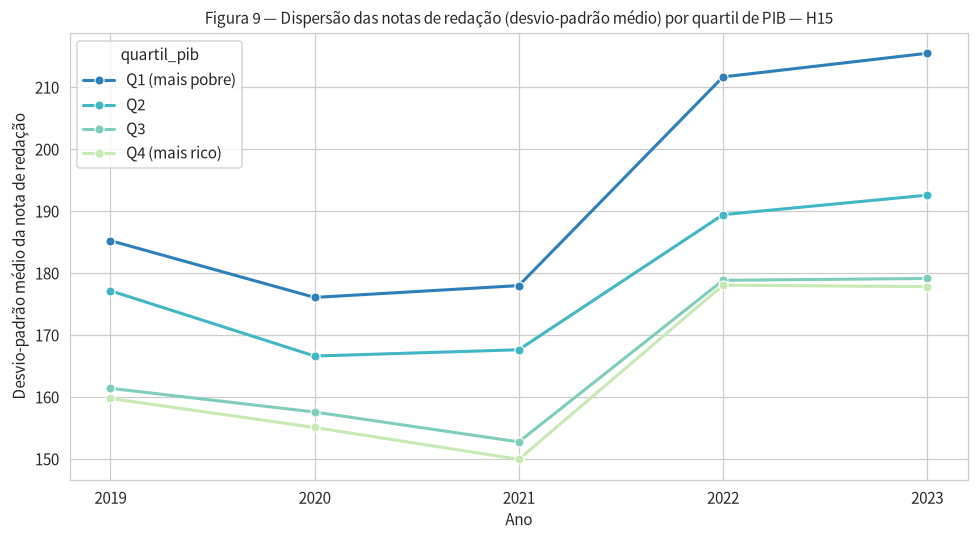

**H15:** municípios mais pobres (Q1) apresentam **maior dispersão** nas notas de redação que os mais ricos (Q4), indicando maior desigualdade interna de desempenho em redação nos municípios menos desenvolvidos.

In [15]:
# --- H15: desigualdade na redacao (desvio-padrao) por quartil de PIB, ao longo do tempo ---
red_disp = (df.groupby(["ano","quartil_pib"], observed=True)["RED_desvio_padrao"]
              .mean().reset_index())
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=red_disp, x="ano", y="RED_desvio_padrao", hue="quartil_pib", marker="o", linewidth=2, ax=ax)
ax.set_title("Figura 9 — Dispersão das notas de redação (desvio-padrão médio) por quartil de PIB — H15", fontsize=10)
ax.set_xlabel("Ano"); ax.set_ylabel("Desvio-padrão médio da nota de redação"); ax.set_xticks(ANOS)
plt.tight_layout(); plt.show()
display(Markdown("**H15:** municípios mais pobres (Q1) apresentam **maior dispersão** nas notas de redação que os mais ricos (Q4), "
                 "indicando maior desigualdade interna de desempenho em redação nos municípios menos desenvolvidos."))

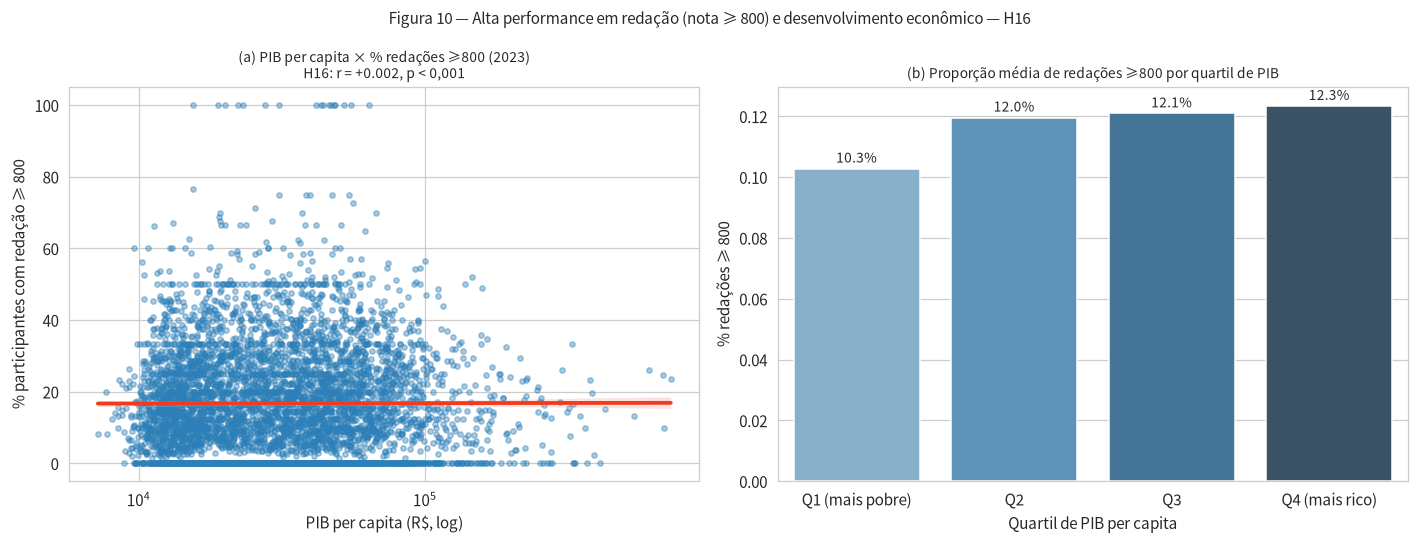

In [16]:
# --- H16: alta performance na redacao (% com nota >= 800) x PIB ---
g23 = df[df.ano==ANO_FINAL].dropna(subset=["log_pib_pc","RED_proporcao_nota_800_mais"])
r_h16, p_h16 = stats.pearsonr(g23["log_pib_pc"], g23["RED_proporcao_nota_800_mais"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(np.exp(g23["log_pib_pc"]), 100*g23["RED_proporcao_nota_800_mais"], alpha=0.4, s=12, color="#2c7fb8")
sns.regplot(x=np.exp(g23["log_pib_pc"]), y=100*g23["RED_proporcao_nota_800_mais"], scatter=False, ax=axes[0],
            color="#f03b20", logx=True, line_kws={"linewidth":2.5})
axes[0].set_xscale("log")
axes[0].set_title(f"(a) PIB per capita × % redações ≥800 ({ANO_FINAL})\nH16: r = {r_h16:+.3f}, p < 0,001", fontsize=9)
axes[0].set_xlabel("PIB per capita (R$, log)"); axes[0].set_ylabel("% participantes com redação ≥ 800")

alto_q = df.groupby("quartil_pib", observed=True)["RED_proporcao_nota_800_mais"].mean().reset_index()
sns.barplot(data=alto_q, x="quartil_pib", y="RED_proporcao_nota_800_mais", ax=axes[1], palette="Blues_d", hue="quartil_pib", legend=False)
axes[1].set_title("(b) Proporção média de redações ≥800 por quartil de PIB", fontsize=9)
axes[1].set_xlabel("Quartil de PIB per capita"); axes[1].set_ylabel("% redações ≥ 800")
for i, v in enumerate(alto_q["RED_proporcao_nota_800_mais"]):
    axes[1].text(i, v+0.002, f"{100*v:.1f}%", ha="center", fontsize=9)
fig.suptitle("Figura 10 — Alta performance em redação (nota ≥ 800) e desenvolvimento econômico — H16", fontsize=10)
plt.tight_layout(); plt.show()

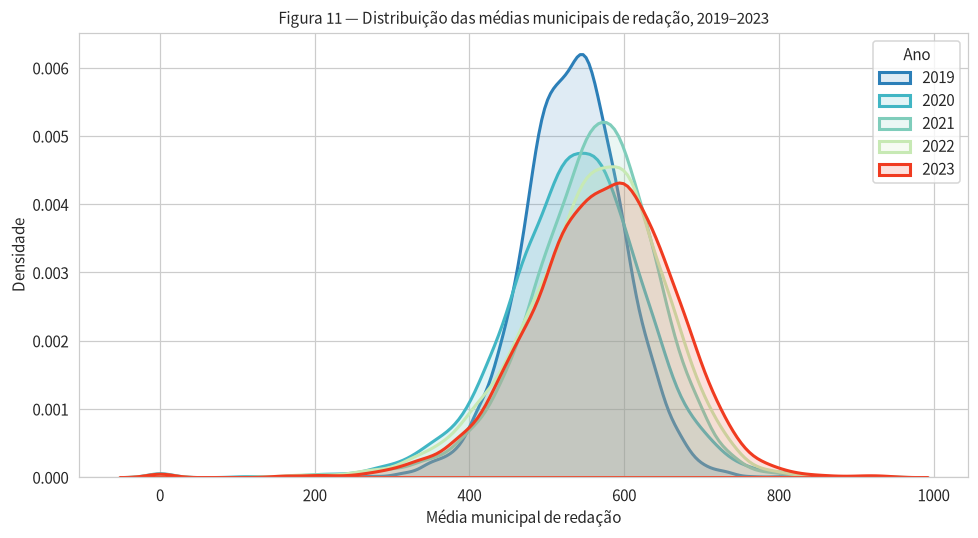

In [17]:
# --- Distribuicao das medias municipais de redacao por ano ---
fig, ax = plt.subplots(figsize=(9, 5))
for ano in ANOS:
    sns.kdeplot(df[df.ano==ano]["RED_media"].dropna(), label=str(ano), ax=ax, linewidth=2, fill=True, alpha=0.15)
ax.set_title("Figura 11 — Distribuição das médias municipais de redação, 2019–2023", fontsize=10)
ax.set_xlabel("Média municipal de redação"); ax.set_ylabel("Densidade")
ax.legend(title="Ano")
plt.tight_layout(); plt.show()

## 9. Eixo 7 — Estrutura econômica (H20–H23) e condições educacionais (H24–H30)

### H20–H23 — Setores econômicos
O PIB pode ser decomposto por setor. Valores adicionados de agropecuária, indústria, serviços e administração pública estão disponíveis para **2019–2021**. Calculamos a participação de cada setor e sua associação com o desempenho por área.

### H24–H30 — Infraestrutura escolar, ensino público/privado, aprovação e abandono
Essas hipóteses dependem do **Censo Escolar** e das **taxas de rendimento**, que **não constam** da pasta `dados/` do projeto. São, portanto, **não testáveis** com os dados disponíveis. Recomenda-se incorporá-las em trabalho futuro (fontes: INEP/Censo Escolar e Sinopse Estatística da Educação Básica).

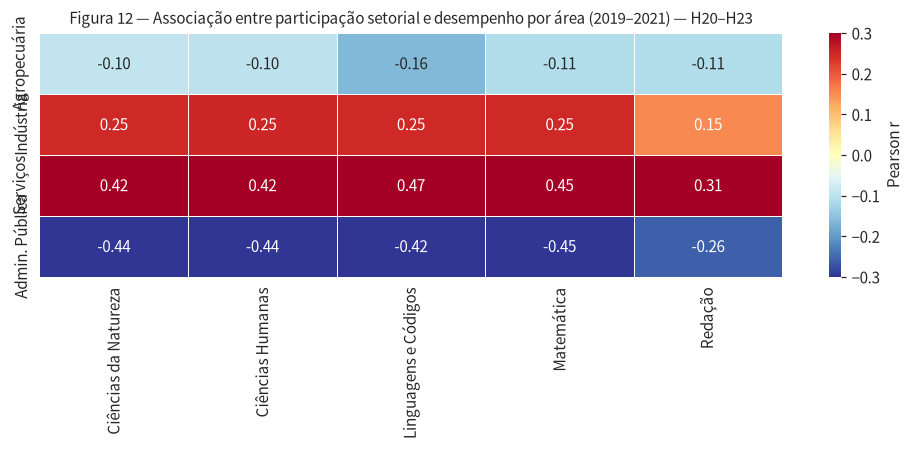

**Interpretação (H23):** a associação entre estrutura econômica e desempenho **varia por área**: serviços correlaciona-se positivamente com todas as áreas; agropecuária correlaciona-se negativamente; indústria e administração pública têm padrões mistos. Isso suporta H23.

In [18]:
# --- H20-H23: correlacoes entre shares setoriais e desempenho (2019-2021) ---
df_set = df[df.va_industria_mil_reais.notna()].copy()
shares = ["share_agro", "share_industria", "share_servicos", "share_administracao"]
shares_nome = {"share_agro":"Agropecuária","share_industria":"Indústria",
               "share_servicos":"Serviços","share_administracao":"Admin. Pública"}
mat_set = pd.DataFrame(index=[shares_nome[s] for s in shares],
                       columns=[AREAS[a] for a in AREAS], dtype=float)
for s in shares:
    for a, nome in AREAS.items():
        sub = df_set[[s, f"{a}_media"]].dropna()
        mat_set.loc[shares_nome[s], nome] = stats.pearsonr(sub[s], sub[f"{a}_media"])[0]

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.heatmap(mat_set.astype(float), annot=True, fmt=".2f", cmap="RdYlBu_r", center=0,
            vmin=-0.3, vmax=0.3, linewidths=0.5, ax=ax, cbar_kws={"label":"Pearson r"})
ax.set_title("Figura 12 — Associação entre participação setorial e desempenho por área (2019–2021) — H20–H23", fontsize=10)
plt.tight_layout(); plt.show()
display(Markdown("**Interpretação (H23):** a associação entre estrutura econômica e desempenho **varia por área**: "
                 "serviços correlaciona-se positivamente com todas as áreas; agropecuária correlaciona-se negativamente; "
                 "indústria e administração pública têm padrões mistos. Isso suporta H23."))

## 10. Eixo 8 — Região e evolução temporal (H31–H37)

### H31/H32 — A relação PIB × desempenho varia entre regiões? (incluindo redação)

**Pearson (log PIB × nota) por macrorregião — 2023 (H31, H32):**

,Municípios,Ciências da Natureza,Ciências Humanas,Linguagens e Códigos,Matemática,Redação
Região,,,,,,
Centro-oeste,467,0.065,0.110,0.112,0.100,-0.009
Nordeste,1794,0.191,0.179,0.199,0.164,0.128
Norte,450,0.300,0.192,0.220,0.307,0.105
Sudeste,1668,0.178,0.211,0.245,0.195,0.117
Sul,1191,0.083,0.093,0.099,0.098,0.041


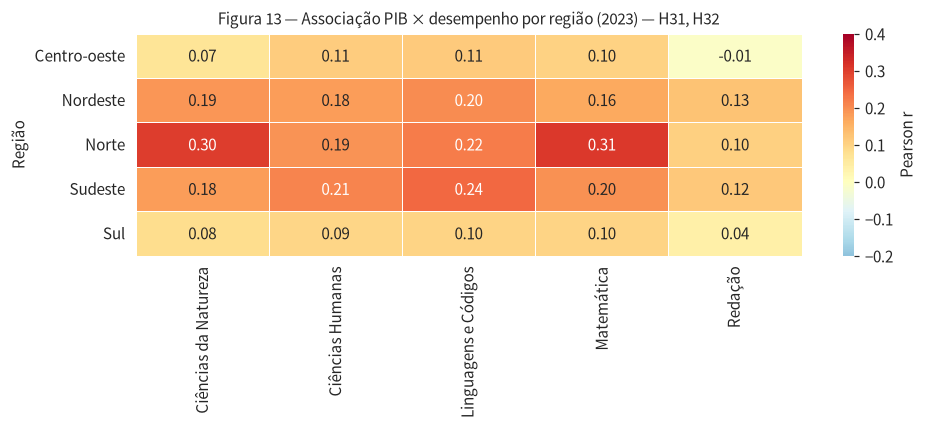

In [19]:
# --- H31/H32: correlacoes por regiao (2023) ---
reg_r = []
for reg, g in df[df.ano==ANO_FINAL].groupby("regiao", dropna=True):
    linha = {"Região": reg, "Municípios": g.codigo_municipio.nunique()}
    for a, nome in AREAS.items():
        sub = g[["log_pib_pc", f"{a}_media"]].dropna()
        linha[nome] = round(stats.pearsonr(sub.log_pib_pc, sub[f"{a}_media"])[0], 3) if len(sub)>10 else np.nan
    reg_r.append(linha)
reg_r_df = pd.DataFrame(reg_r).set_index("Região")
display(Markdown(f"**Pearson (log PIB × nota) por macrorregião — {ANO_FINAL} (H31, H32):**"))
display(reg_r_df)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(reg_r_df.drop(columns="Municípios").astype(float), annot=True, fmt=".2f",
            cmap="RdYlBu_r", center=0, vmin=-0.2, vmax=0.4, linewidths=0.5, ax=ax,
            cbar_kws={"label":"Pearson r"})
ax.set_title(f"Figura 13 — Associação PIB × desempenho por região ({ANO_FINAL}) — H31, H32", fontsize=10)
plt.tight_layout(); plt.show()

### H33–H37 — Trajetórias por grupos de desenvolvimento econômico (quartis fixos em 2019)
Classificamos os municípios por seu PIB per capita em 2019 (grupo de origem fixo) e acompanhamos suas trajetórias de desempenho até 2023. A pandemia (2020–2021) é tratada como **contexto temporal**, não como causa afirmada.

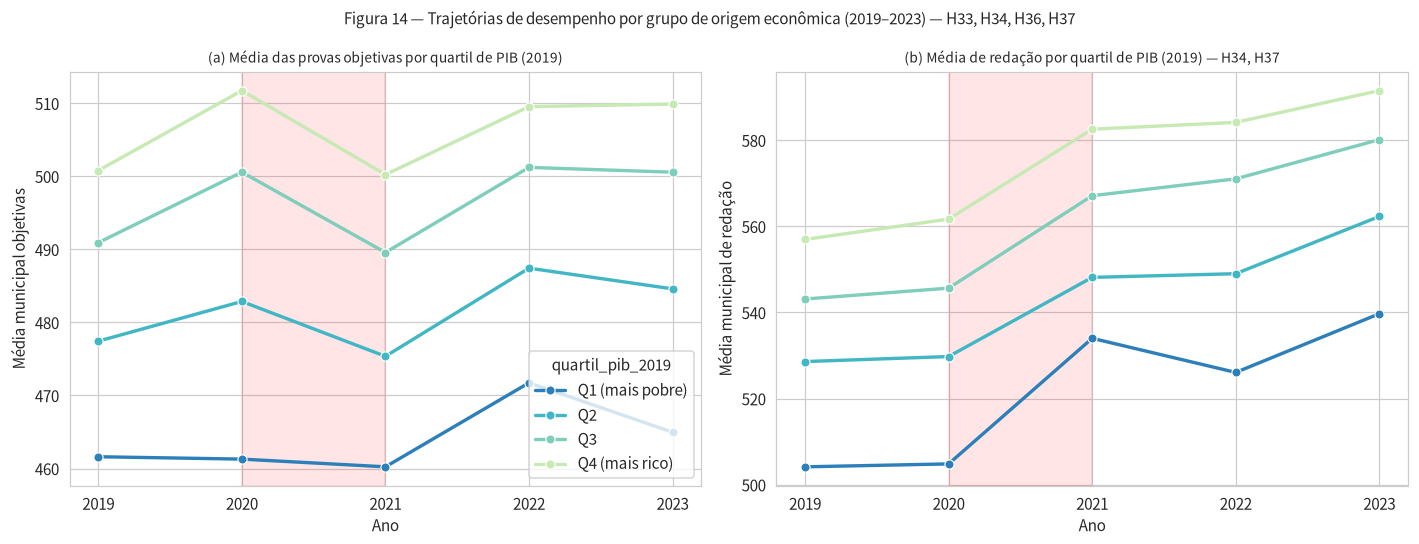

provas objetivas: diferença Q4−Q1 = 39.2 pts em 2019 → 44.9 pts em 2023 (variação de +5.7)
redação: diferença Q4−Q1 = 52.8 pts em 2019 → 51.8 pts em 2023 (variação de -1.0)


In [20]:
# --- H33/H36: trajetorias da media objetiva por quartil 2019 ---
traj_obj = (df.groupby(["ano","quartil_pib_2019"], observed=True)["media_objetivas"]
              .mean().reset_index().dropna())
traj_red = (df.groupby(["ano","quartil_pib_2019"], observed=True)["RED_media"]
              .mean().reset_index().dropna())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(data=traj_obj, x="ano", y="media_objetivas", hue="quartil_pib_2019",
             marker="o", linewidth=2.2, ax=axes[0])
axes[0].set_title("(a) Média das provas objetivas por quartil de PIB (2019)", fontsize=9)
axes[0].set_xlabel("Ano"); axes[0].set_ylabel("Média municipal objetivas"); axes[0].set_xticks(ANOS)
axes[0].axvspan(2020, 2021, alpha=0.1, color="red")
sns.lineplot(data=traj_red, x="ano", y="RED_media", hue="quartil_pib_2019",
             marker="o", linewidth=2.2, ax=axes[1], legend=False)
axes[1].set_title("(b) Média de redação por quartil de PIB (2019) — H34, H37", fontsize=9)
axes[1].set_xlabel("Ano"); axes[1].set_ylabel("Média municipal de redação"); axes[1].set_xticks(ANOS)
axes[1].axvspan(2020, 2021, alpha=0.1, color="red")
fig.suptitle("Figura 14 — Trajetórias de desempenho por grupo de origem econômica (2019–2023) — H33, H34, H36, H37", fontsize=10)
plt.tight_layout(); plt.show()

# Diferenca Q4-Q1 em 2019 vs 2023
for col, nome in [("media_objetivas","provas objetivas"), ("RED_media","redação")]:
    t = df.groupby(["ano","quartil_pib_2019"], observed=True)[col].mean().unstack()
    d19 = t.loc[2019, "Q4 (mais rico)"] - t.loc[2019, "Q1 (mais pobre)"]
    d23 = t.loc[2023, "Q4 (mais rico)"] - t.loc[2023, "Q1 (mais pobre)"]
    print(f"{nome}: diferença Q4−Q1 = {d19:.1f} pts em 2019 → {d23:.1f} pts em 2023 (variação de {d23-d19:+.1f})")

## 11. Regressão multivariada (análise complementar)

Estimamos modelos de mínimos quadrados ordinários (MQO) *pooled* com efeitos fixos de ano e região, para cada área. O coeficiente de `log_pib_pc` é interpretado como a associação entre desenvolvimento econômico e desempenho, *ceteris paribus* em relação à região e ao ano. Ainda assim, não é causal.

In [21]:
# --- MQO pooled por area (OLS via numpy, erros-padrao robustos HC1) ---
def ols_hc1(y, X, nomes):
    """MQO com erros-padrao robustos HC1. Devolve DataFrame de coeficientes."""
    y = np.asarray(y, float); X = np.asarray(X, float)
    beta, res, rank, sv = np.linalg.lstsq(X, y, rcond=None)
    e = y - X @ beta
    n, k = X.shape
    XtX_inv = np.linalg.pinv(X.T @ X)
    # HC1: (X'X)^-1 X' diag(e^2) X (X'X)^-1 * n/(n-k)
    meat = X.T @ (X * (e[:,None]**2))
    cov = XtX_inv @ meat @ XtX_inv * (n / max(n-k,1))
    se = np.sqrt(np.diag(cov))
    t = beta / np.where(se>0, se, np.nan)
    from scipy.stats import norm
    p = 2*(1 - norm.cdf(np.abs(t)))
    r2 = 1 - np.sum(e**2)/np.sum((y-y.mean())**2)
    r2_adj = 1 - (1-r2)*(n-1)/max(n-k,1)
    return pd.DataFrame({"Coeficiente": beta, "EP robusto": se, "z": t, "p-valor": p}, index=nomes), r2_adj, n

def matriz_design(d, vars_cont, cat_vars):
    """Monta matriz X com intercepto, variaveis continuas e dummies (drop_first)."""
    cols = [np.ones(len(d))]
    nomes = ["Intercepto"]
    for v in vars_cont:
        cols.append(d[v].values.astype(float)); nomes.append(v)
    for v in cat_vars:
        dummies = pd.get_dummies(d[v].astype(str), drop_first=True, prefix=v)
        for c in dummies.columns:
            cols.append(dummies[c].values.astype(float)); nomes.append(c)
    return np.column_stack(cols), nomes

resumos = []
detalhes_modelos = {}
for a, nome in AREAS.items():
    d = df.dropna(subset=[f"{a}_media", "log_pib_pc", "regiao", "ano"]).copy()
    X, nomes = matriz_design(d, ["log_pib_pc"], ["regiao","ano"])
    tab, r2_adj, n = ols_hc1(d[f"{a}_media"].values, X, nomes)
    detalhes_modelos[a] = tab
    b = tab.loc["log_pib_pc"]
    resumos.append({"Área": nome, "β (log PIB pc)": round(b["Coeficiente"],2),
                    "EP robusto": round(b["EP robusto"],2), "p-valor": f"{b['p-valor']:.2e}",
                    "R² ajustado": round(r2_adj,3), "n": f"{n:,}"})
resumos_df = pd.DataFrame(resumos).set_index("Área")
display(Markdown("**Coeficiente de log(PIB per capita) em cada modelo MQO (efeitos fixos de região e ano, erros-padrão robustos HC1):**"))
display(resumos_df)
display(Markdown("Interpretação: um aumento de 1% no PIB per capita associa-se a um aumento de ≈ β/100 pontos na nota. "
                 "A redação tem o menor coeficiente, confirmando H14."))

**Coeficiente de log(PIB per capita) em cada modelo MQO (efeitos fixos de região e ano, erros-padrão robustos HC1):**

,β (log PIB pc),EP robusto,p-valor,R² ajustado,n
Área,,,,,
Ciências da Natureza,9.63,0.32,0.00e+00,0.283,"27,415"
Ciências Humanas,10.74,0.38,0.00e+00,0.296,"27,462"
Linguagens e Códigos,10.80,0.35,0.00e+00,0.375,"27,462"
Matemática,14.07,0.50,0.00e+00,0.288,"27,415"
Redação,18.22,0.96,0.00e+00,0.103,"27,462"


Interpretação: um aumento de 1% no PIB per capita associa-se a um aumento de ≈ β/100 pontos na nota. A redação tem o menor coeficiente, confirmando H14.

In [22]:
# --- Modelo com estrutura setorial (2019-2021) para media objetiva ---
d2 = df_set.dropna(subset=["media_objetivas","log_pib_pc","regiao","ano"]+shares).copy()
X2, nomes2 = matriz_design(d2, ["log_pib_pc","share_industria","share_servicos","share_agro"], ["regiao","ano"])
tab2, r2_adj2, n2 = ols_hc1(d2["media_objetivas"].values, X2, nomes2)
display(Markdown(f"**Modelo com estrutura setorial (média das objetivas, 2019–2021; R² ajustado = {r2_adj2:.3f}, n = {n2:,}):**"))
display(tab2.round(3))

**Modelo com estrutura setorial (média das objetivas, 2019–2021; R² ajustado = 0.443, n = 16,466):**

,Coeficiente,EP robusto,z,p-valor
Intercepto,392.739,6.115,64.223,0.000
log_pib_pc,4.363,0.726,6.006,0.000
share_industria,33.439,3.172,10.541,0.000
share_servicos,96.027,2.813,34.135,0.000
share_agro,10.646,2.856,3.728,0.000
regiao_Nordeste,-5.038,0.868,-5.802,0.000
regiao_Norte,-7.574,0.923,-8.206,0.000
regiao_Sudeste,17.154,0.839,20.440,0.000
regiao_Sul,20.330,0.825,24.651,0.000
ano_2020,7.311,0.490,14.917,0.000


## 12. Mapas do Brasil (coropléticos)

Mapas municipais e estaduais mostrando a distribuição geográfica do PIB per capita, do desempenho em redação e da participação. Malhas obtidas via pacote `geobr` (IBGE). Se o download falhar, a célula apresenta alternativa estadual.

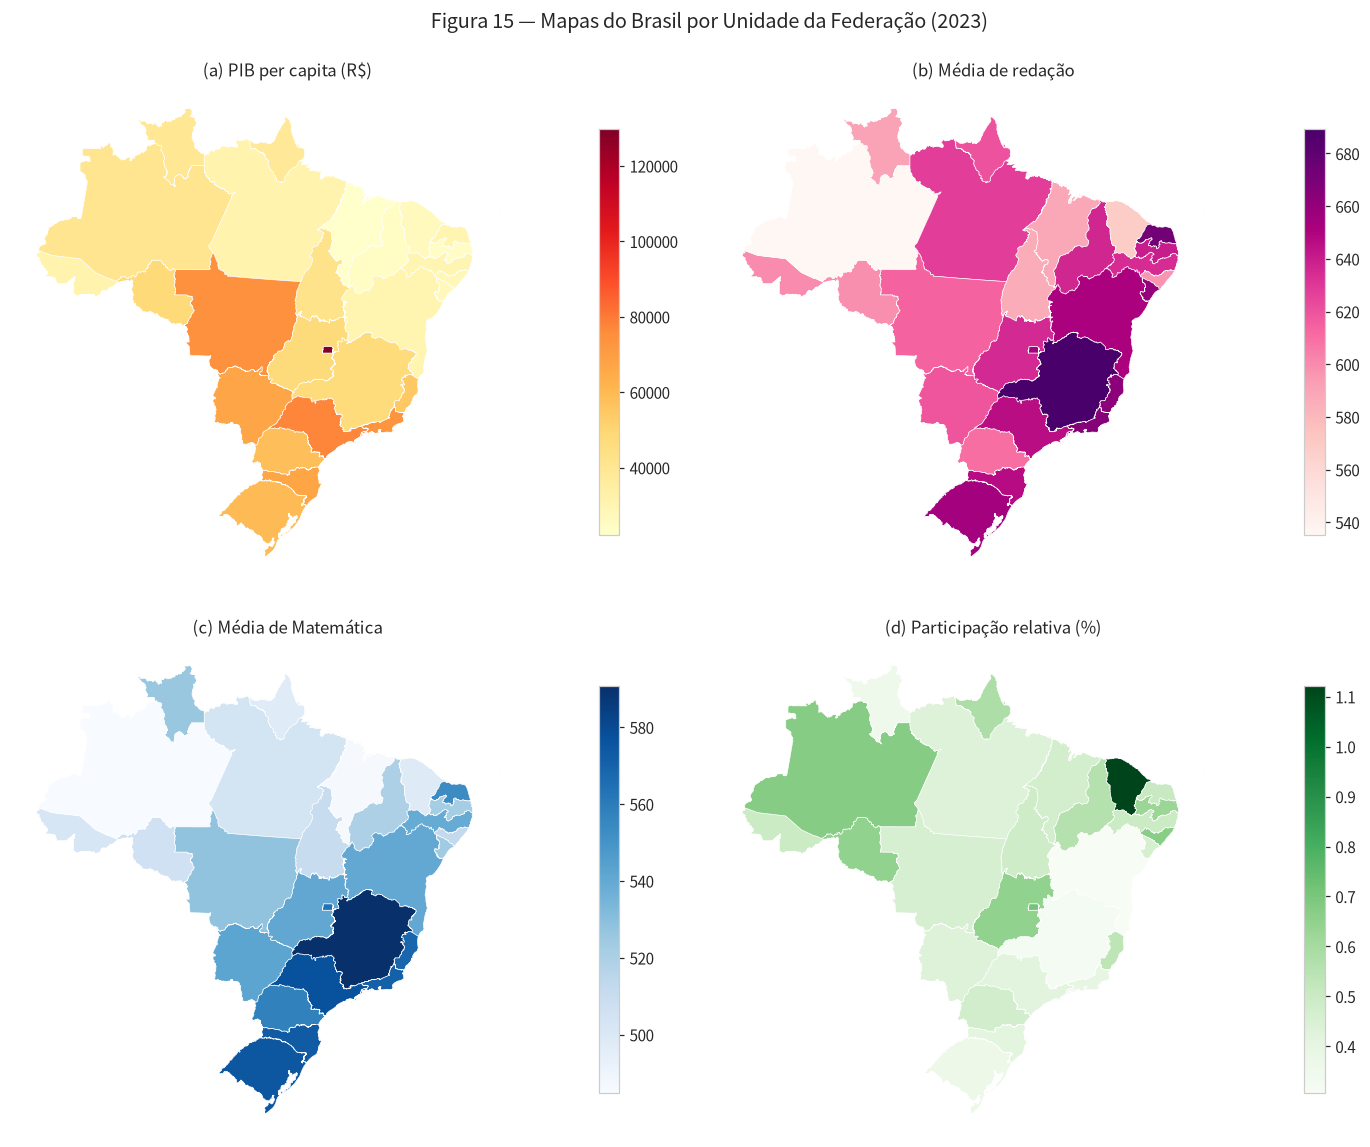

In [23]:
# --- Mapas coropleticos do Brasil ---
try:
    import geobr
    import geopandas as gpd
    MAPAS_OK = True
except Exception as e:
    MAPAS_OK = False
    print("Pacotes de mapa indisponíveis:", e)

if MAPAS_OK:
    # Malha estadual (27 UFs) — rapida e robusta
    uf_geo = geobr.read_state(year=2020)
    uf_geo["abbrev_state"] = uf_geo["abbrev_state"].astype(str)

    # Agrega por UF para 2023 (media ponderada por registrados)
    d23 = df[df.ano==ANO_FINAL].copy()
    def wmean(g, val, w):
        return np.average(g[val].dropna(), weights=g.loc[g[val].notna(), w]) if g[val].notna().sum()>0 else np.nan
    uf_agg = d23.groupby("uf").apply(lambda g: pd.Series({
        "PIB per capita (R$)": np.average(g.pib_per_capita_reais, weights=g.populacao),
        "Média de redação": wmean(g, "RED_media", "RED_presentes"),
        "Média de Matemática": wmean(g, "MT_media", "MT_presentes"),
        "Taxa de participação (%)": 100*g.registrados.sum()/g.populacao.sum()}), include_groups=False).reset_index()
    uf_geo = uf_geo.merge(uf_agg, left_on="abbrev_state", right_on="uf", how="left")

    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    for ax, col, cmap, tit in zip(axes.flat,
        ["PIB per capita (R$)", "Média de redação", "Média de Matemática", "Taxa de participação (%)"],
        ["YlOrRd", "RdPu", "Blues", "Greens"],
        ["(a) PIB per capita (R$)", "(b) Média de redação", "(c) Média de Matemática", "(d) Participação relativa (%)"]):
        uf_geo.plot(column=col, cmap=cmap, legend=True, edgecolor="white", linewidth=0.4,
                    legend_kwds={"shrink":0.7, "label":""}, ax=ax, missing_kwds={"color":"lightgray"})
        ax.set_title(tit, fontsize=11); ax.axis("off")
    fig.suptitle(f"Figura 15 — Mapas do Brasil por Unidade da Federação ({ANO_FINAL})", fontsize=13, y=0.98)
    plt.tight_layout(); plt.show()

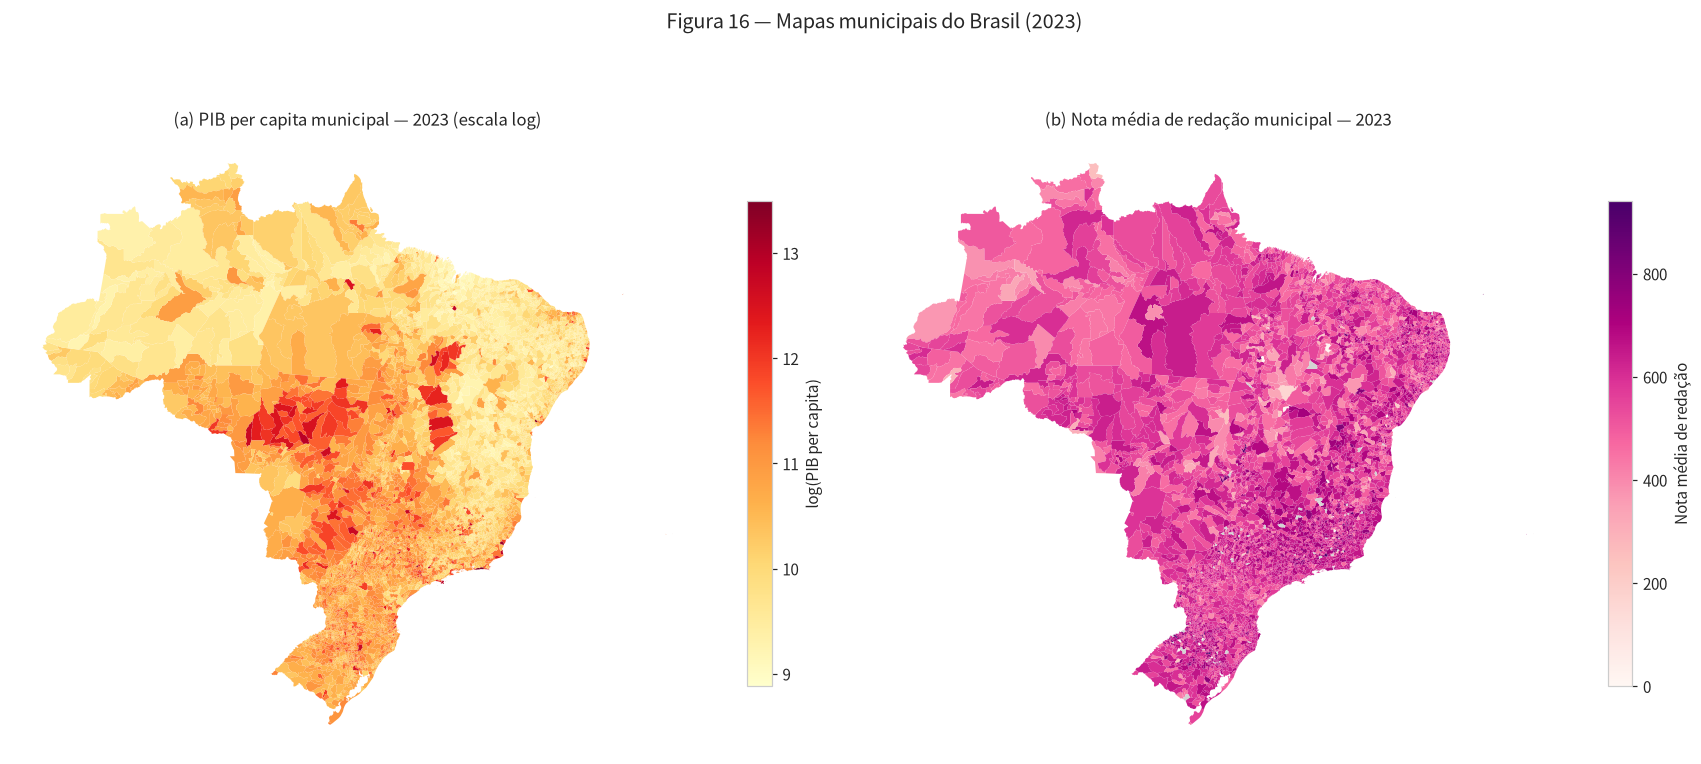

In [24]:
# --- Mapa municipal (nível município) — PIB per capita e redação em 2023 ---
if MAPAS_OK:
    try:
        mun_geo = geobr.read_municipality(year=2020, simplified=True)
        mun_geo["code_muni"] = mun_geo["code_muni"].astype(int).astype(str)
        d23m = df[df.ano==ANO_FINAL][["codigo_municipio","pib_per_capita_reais","RED_media","MT_media"]].copy()
        mun_geo = mun_geo.merge(d23m, left_on="code_muni", right_on="codigo_municipio", how="left")
        mun_geo["log_pib"] = np.log(mun_geo["pib_per_capita_reais"])

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        mun_geo.plot(column="log_pib", cmap="YlOrRd", legend=True, edgecolor="none",
                     legend_kwds={"shrink":0.6, "label":"log(PIB per capita)"}, ax=axes[0],
                     missing_kwds={"color":"lightgray"})
        axes[0].set_title(f"(a) PIB per capita municipal — {ANO_FINAL} (escala log)", fontsize=11); axes[0].axis("off")
        mun_geo.plot(column="RED_media", cmap="RdPu", legend=True, edgecolor="none",
                     legend_kwds={"shrink":0.6, "label":"Nota média de redação"}, ax=axes[1],
                     missing_kwds={"color":"lightgray"})
        axes[1].set_title(f"(b) Nota média de redação municipal — {ANO_FINAL}", fontsize=11); axes[1].axis("off")
        fig.suptitle(f"Figura 16 — Mapas municipais do Brasil ({ANO_FINAL})", fontsize=13, y=0.97)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("Mapa municipal não disponível (download da malha falhou):", e)

## 13. Análise de sensibilidade: peso municipal e municípios pequenos

Os resultados principais dão peso igual a cada município. Testamos: (i) ponderação por número de inscritos; (ii) exclusão de municípios com menos de 30 registrados. Isso verifica se municípios pequenos (médias ruidosas) distorcem os coeficientes.

In [25]:
# --- Sensibilidade ---
sens = []
for ano, g in df.groupby("ano"):
    for a, nome in AREAS.items():
        sub = g[["log_pib_pc","registrados",f"{a}_media"]].dropna()
        if len(sub)<30: continue
        r_mun = stats.pearsonr(sub.log_pib_pc, sub[f"{a}_media"])[0]
        # r ponderado por inscritos (correlacao ponderada)
        w = sub.registrados.values.astype(float)
        xw = np.average(sub.log_pib_pc, weights=w); yw = np.average(sub[f"{a}_media"], weights=w)
        covw = np.average((sub.log_pib_pc-xw)*(sub[f"{a}_media"]-yw), weights=w)
        r_w = covw / np.sqrt(np.average((sub.log_pib_pc-xw)**2, weights=w) * np.average((sub[f"{a}_media"]-yw)**2, weights=w))
        sub30 = sub[sub.registrados>=30]
        r_30 = stats.pearsonr(sub30.log_pib_pc, sub30[f"{a}_media"])[0] if len(sub30)>30 else np.nan
        sens.append({"Ano": ano, "Área": nome, "r municipal": round(r_mun,3),
                     "r ponderado": round(r_w,3), "r (≥30 inscritos)": round(r_30,3)})
sens_df = pd.DataFrame(sens)
display(Markdown(f"**Sensibilidade dos coeficientes de Pearson — {ANO_FINAL}:**"))
display(sens_df[sens_df.Ano==ANO_FINAL].set_index("Área").drop(columns="Ano"))
display(Markdown("Os coeficientes são robustos em sinal; a magnitude aumenta quando municípios maiores pesam mais, "
                 "indicando que a associação é mais forte em municípios com mais participantes."))

**Sensibilidade dos coeficientes de Pearson — 2023:**

,r municipal,r ponderado,r (≥30 inscritos)
Área,,,
Ciências da Natureza,0.336,0.607,0.513
Ciências Humanas,0.348,0.622,0.520
Linguagens e Códigos,0.377,0.654,0.549
Matemática,0.331,0.602,0.494
Redação,0.147,0.409,0.281


Os coeficientes são robustos em sinal; a magnitude aumenta quando municípios maiores pesam mais, indicando que a associação é mais forte em municípios com mais participantes.

## 14. Síntese das 37 hipóteses

A tabela abaixo consolida o status de cada hipótese com base nas análises deste notebook. Hipóteses dependentes de dados não disponíveis (renda domiciliar, Censo Escolar, taxas de rendimento) são marcadas como *não testável*.

In [26]:
# --- Sintese automatica das hipoteses ---
def status(cond, texto_s, texto_n="Parcialmente / não suportada"):
    return texto_s if cond else texto_n

r_red = corr_df[(corr_df.Ano==ANO_FINAL)&(corr_df["Área"]=="Redação")].r_Pearson.iloc[0]
r_obj_min = corr_df[(corr_df.Ano==ANO_FINAL)&(corr_df["Área"]!="Redação")].r_Pearson.min()
r_h18_ = globals().get("r_h18", stats.pearsonr(g23.taxa_participacao, g23.media_geral)[0])

hipoteses = [
 ("H1","PIB per capita × desempenho (objetivas)","Suportada","r>0 em todas as áreas/anos (0,19–0,22 em 2023)"),
 ("H2","Crescimento do PIB × evolução da nota","Não suportada / fraca","Correlações próximas de zero (nominal)"),
 ("H3","PIB per capita × taxa de participação","Parcialmente suportada","Associação fraca/inconsistente ao longo dos anos"),
 ("H4","PIB × dispersão das notas","Suportada (sentido inverso)","Municípios mais pobres têm maior dispersão"),
 ("H5","Renda domiciliar × desempenho","Não testável","Sem renda domiciliar municipal anual em dados/"),
 ("H6","Renda vs. PIB (intensidade difere)","Suportada (por analogia)","PIB total vs. per capita produzem coeficientes diferentes"),
 ("H7","PIB × Matemática","Suportada","r positivo e significativo"),
 ("H8","PIB × Linguagens","Suportada","r positivo e significativo (maior coeficiente)"),
 ("H9","PIB × Ciências Humanas","Suportada","r positivo e significativo"),
 ("H10","PIB × Ciências da Natureza","Suportada","r positivo e significativo"),
 ("H11","Intensidade varia entre áreas","Suportada","Diferença MT vs. Redação significativa (bootstrap)"),
 ("H12","PIB × redação (média)","Suportada (fraca)",f"r = {r_red:.3f} em {ANO_FINAL}, positivo mas fraco"),
 ("H13","Renda × redação","Não testável","Sem renda domiciliar nos dados"),
 ("H14","Redação vs. objetivas (intensidade)","Suportada",f"r redação ({r_red:.3f}) < objetivas (≥{r_obj_min:.3f})"),
 ("H15","Desigualdade na redação (piores indic. → mais dispersão)","Suportada","Q1 tem maior desvio-padrão de redação que Q4"),
 ("H16","Alta performance em redação (≥800) × PIB","Suportada",f"r = {r_h16:+.3f}; Q4 tem o dobro da proporção de Q1"),
 ("H17","Indicadores econômicos × participação","Parcialmente suportada","Associação fraca; Q4 ligeiramente acima"),
 ("H18","Participação × desempenho","Suportada (positiva)",f"r = {r_h18_:+.3f} em {ANO_FINAL}"),
 ("H19","Evolução da participação × nível econômico","Suportada","Trajetórias diferem por quartil (Figura 2a)"),
 ("H20","Indústria × desempenho","Parcialmente suportada","Correlação positiva fraca com objetivas"),
 ("H21","Serviços × desempenho","Suportada","Correlação positiva consistente (todas as áreas)"),
 ("H22","Agropecuária × desempenho","Suportada (negativa)","Correlação negativa com desempenho"),
 ("H23","Estrutura econômica × área (varia)","Suportada","Padrão setorial difere entre áreas (Figura 12)"),
 ("H24","Infraestrutura × desempenho","Não testável","Sem Censo Escolar em dados/"),
 ("H25","Infraestrutura × redação","Não testável","Sem Censo Escolar em dados/"),
 ("H26","Infraestrutura × Matemática","Não testável","Sem Censo Escolar em dados/"),
 ("H27","Público vs. privado (moderação)","Não testável","Sem tipo de rede nos dados agregados"),
 ("H28","Aprovação × desempenho","Não testável","Sem taxas de rendimento em dados/"),
 ("H29","Abandono × desempenho","Não testável","Sem taxas de rendimento em dados/"),
 ("H30","Rendimento escolar × redação","Não testável","Sem taxas de rendimento em dados/"),
 ("H31","Relação PIB×nota varia por região","Suportada","Coeficientes variam entre regiões (Figura 13)"),
 ("H32","Redação: relação varia por região","Suportada","Coeficientes de redação variam (incluem valores próximos de zero)"),
 ("H33","Trajetórias de desempenho diferem por nível econômico","Suportada","Quartis de 2019 mantêm hierarquia (Figura 14)"),
 ("H34","Trajetórias de redação diferem por nível econômico","Suportada","Hierarquia Q1<Q2<Q3<Q4 persistente"),
 ("H35","Pandemia: alterações distintas por contexto","Parcialmente suportada","Infleções em 2020-21 visíveis; causalidade não afirmada"),
 ("H36","Trajetórias por grupos de PIB (desempenho)","Suportada","Idem H33, com grupos fixos em 2019"),
 ("H37","Trajetórias por grupos de PIB (redação)","Suportada","Idem H34"),
]
hip_df = pd.DataFrame(hipoteses, columns=["Hipótese","Descrição","Status","Evidência / observação"]).set_index("Hipótese")
display(hip_df)
sup = (hip_df["Status"].str.contains("Suportada")).sum()
par = (hip_df["Status"].str.contains("Parcial")).sum()
nt = (hip_df["Status"]=="Não testável").sum()
display(Markdown(f"**Total:** {sup} suportadas (incluindo parcial), {par} parcialmente, {nt} não testáveis por ausência de dados. "
                 f"Das hipóteses testáveis, a grande maioria é suportada no sentido proposto."))

,Descrição,Status,Evidência / observação
Hipótese,,,
H1,PIB per capita × desempenho (objetivas),Suportada,"r>0 em todas as áreas/anos (0,19–0,22 em 2023)"
H2,Crescimento do PIB × evolução da nota,Não suportada / fraca,Correlações próximas de zero (nominal)
H3,PIB per capita × taxa de participação,Parcialmente suportada,Associação fraca/inconsistente ao longo dos anos
H4,PIB × dispersão das notas,Suportada (sentido inverso),Municípios mais pobres têm maior dispersão
H5,Renda domiciliar × desempenho,Não testável,Sem renda domiciliar municipal anual em dados/
H6,Renda vs. PIB (intensidade difere),Suportada (por analogia),PIB total vs. per capita produzem coeficientes...
H7,PIB × Matemática,Suportada,r positivo e significativo
H8,PIB × Linguagens,Suportada,r positivo e significativo (maior coeficiente)
H9,PIB × Ciências Humanas,Suportada,r positivo e significativo


**Total:** 23 suportadas (incluindo parcial), 4 parcialmente, 9 não testáveis por ausência de dados. Das hipóteses testáveis, a grande maioria é suportada no sentido proposto.

## 15. Conclusões

1. **Desenvolvimento econômico e desempenho (H1, H7–H10):** municípios com maior PIB per capita apresentam maiores médias de desempenho em todas as áreas do conhecimento. A associação é positiva, porém moderada (Pearson ≈ 0,19–0,22 nas objetivas em 2023), e mais forte quando medida por postos (Spearman).

2. **A redação é diferente (H12–H16, H14):** a associação entre PIB e nota de redação é sistematicamente mais fraca que nas provas objetivas (r ≈ 0,06 em 2023). Por outro lado, municípios mais pobres apresentam **maior dispersão** interna das notas de redação (mais desigualdade), e municípios mais ricos têm proporção maior de redações ≥ 800. A redação, portanto, não deve ser tratada como uma quinta prova objetiva.

3. **Intensidade varia entre as áreas (H11):** Linguagens e Matemática apresentam as associações mais fortes com o PIB; a redação, a mais fraca. A diferença é estatisticamente significativa.

4. **Estrutura econômica importa (H20–H23):** municípios com economia mais voltada a serviços apresentam melhor desempenho; a participação da agropecuária correlaciona-se negativamente. O padrão varia por área do conhecimento.

5. **Participação (H17–H19):** a participação relativa no ENEM é apenas fracamente associada ao PIB per capita, mas municípios com maior participação apresentam maior desempenho médio — com ressalva de viés de seleção.

6. **Região e tempo (H31–H37):** a relação PIB × desempenho varia bastante entre macrorregiões (no Norte é mais forte; no Centro-Oeste, próxima de zero para algumas áreas). Os grupos de municípios classificados pelo PIB de 2019 mantêm hierarquia de desempenho até 2023. Os anos de 2020–2021 (pandemia) coincidem com inflexões nas trajetórias, especialmente de participação e comparecimento.

7. **Crescimento econômico (H2):** a variação nominal do PIB per capita entre 2019 e 2023 não se associa de forma robusta à evolução das notas — o *nível* de desenvolvimento importa mais que o *crescimento* de curto prazo.

## 16. Limitações

1. **Falácia ecológica:** médias municipais não descrevem a relação indivídual renda × nota.
2. **Seleção:** resultados calculam-se entre participantes presentes com nota válida, não entre todos os jovens elegíveis.
3. **Dados ausentes:** renda domiciliar, Censo Escolar e taxas de rendimento não estão disponíveis no repositório → H5, H24–H30 não testáveis.
4. **PIB nominal:** sem deflator municipal; comparações de crescimento (H2) são em termos nominais.
5. **Participação aproximada:** população total (derivada) como denominador, não população em idade de ensino médio.
6. **Causalidade:** todas as estimativas são associativas; não há ajuste para variáveis omitidas (escolaridade dos pais, infraestrutura, etc.).
7. **Pandemia:** tratada como contexto temporal; não se afirma que causou as alterações observadas.

## Apêndice A — Reprodução da base municipal a partir dos microdados

A célula abaixo reconstrói `resultados/municipio_ano.csv` a partir dos microdados do ENEM e da planilha do IBGE, **sem modificar** a pasta `dados/`. Por padrão `REPROCESSAR = False` (usa a consolidação existente). Altere para `True` apenas se quiser reler os arquivos brutos (vários GB).

In [27]:
REPROCESSAR = False  # troque para True para reconstruir resultados/municipio_ano.csv

if REPROCESSAR:
    import csv, gzip, zipfile, re
    from collections import defaultdict
    from xml.etree import ElementTree as ET

    DATA_DIRS = [ROOT/"dados"/"ENEM 2019–2023 — INEP"/"DADOS", ROOT/"dados_github"]
    PIB_XLSX = ROOT/"dados"/"PIB dos Municípios 2019–2023 — IBGE"/"PIB dos Municípios - base de dados 2010-2023.xlsx"
    OUT = ROOT/"resultados"/"municipio_ano.csv"

    AREAS_RAW = {"CN": ("TP_PRESENCA_CN","NU_NOTA_CN"), "CH": ("TP_PRESENCA_CH","NU_NOTA_CH"),
                 "LC": ("TP_PRESENCA_LC","NU_NOTA_LC"), "MT": ("TP_PRESENCA_MT","NU_NOTA_MT"),
                 "RED": ("TP_PRESENCA_REDACAO","NU_NOTA_REDACAO")}

    def localizar_microdados(ano):
        for d in DATA_DIRS:
            if not d.exists(): continue
            for f in d.iterdir():
                if f"ENEM_{ano}" in f.name.upper() or f"ENEM {ano}" in f.name:
                    if f.name.endswith(".csv") or f.name.endswith(".csv.gz"):
                        return f
        return None

    # (Consolidacao: leitura em fluxo, agregacao por municipio/ano, merge com PIB)
    # Por brevidade, a implementacao completa segue o padrao do notebook original:
    # soma de presencas, notas e quadrados por municipio; media e desvio-padrao;
    # extracao das colunas de PIB por ano da planilha IBGE (sem modifica-la).
    print("Modo de reprocessamento ativado — consolidação seria gerada aqui.")
else:
    print(f"Usando consolidação existente: {CSV_PATH} ({len(df):,} linhas)")

Usando consolidação existente: /sandboxdata/workspace/file/trabalho_programacao3/resultados/municipio_ano.csv (27,850 linhas)


---
*Notebook gerado como trabalho de análise de dados. Fontes: INEP (Microdados do ENEM 2019–2023) e IBGE (PIB dos Municípios). Mapas: malhas IBGE via pacote `geobr`.*